In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [2]:
with open('/Users/lisepauwels/phd/data/sps-measurements/results_chroma/smoothed_tune.json', 'r') as fid:
    data = json.load(fid)

In [5]:
coeffs_qx =np.polyfit(data['delta'], data['qx'], 4)
coeffs_qy =np.polyfit(data['delta'], data['qy'], 4)

In [11]:
coeffs_qx

array([-4.81007927e+06, -9.05132921e+04,  2.04483213e+02,  7.07408619e+00,
        1.31354673e-01])

In [7]:
def matchSummary(opt):
    for tt in opt._err.targets:
        if tt.line:
           nn=" ".join((tt.line,)+tt.tar)
           rr=tt.action.run()[tt.line][tt.tar]
        else:
           nn=tt.tar
           nn=" ".join(nn)
           rr=tt.action.run()[tt.tar]
        if(type(tt.value)==xt.match.LessThan):
            vv=tt.value.upper
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}') 
        elif(type(tt.value)==xt.match.GreaterThan):
            vv=tt.value.lower
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
        elif(hasattr(tt,'rhs')):
            vv=tt.rhs
            dd=(rr-vv)
            if(tt.ineq_sign=='>'):
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
            else:
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}')   
        else:
            vv=tt.value
            dd=(rr-vv)
            dd=np.abs(dd)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {dd<tt.tol}')

In [8]:
class nonlin_chroma(xd.Action):
    def __init__(self, line):
        self.line = line

    def run(self):
        deg = 4

        delta_values = np.arange(-3e-3, 3e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss4d(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]
        print("qx coeff:", qx_coeff)

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]
        print("qy coeff:", qy_coeff)

        return {'qx0': qx_coeff[4], 'qy0': qy_coeff[4], 
                'qx1': qx_coeff[3], 'qy1': qy_coeff[3], 
                'qx2': qx_coeff[2], 'qy2': qy_coeff[2], 
                'qx3': qx_coeff[1], 'qy3': qy_coeff[1], 
                'qx4': qx_coeff[0], 'qy4': qy_coeff[0], 
                # 'qx5': qx_coeff[2], 'qy5': qy_coeff[2], 
                # 'qx6': qx_coeff[1], 'qy6': qy_coeff[1], 
                # 'qx7': qx_coeff[0], 'qy7': qy_coeff[0], 
               }

In [9]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

In [10]:
line = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
tt = line.get_table()

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.extend_knl_ksl(order=9, element_names=list(mba)+list(mbb)+list(qf)+list(qd))
#Creating knobs for the non-linear chromaticity fit
env['b3_mba'] = 0
env['b3_mbb'] = 0
env['b4_qd'] = 0
env['b4_qf'] = 0
env['b5_mba'] = 0
env['b5_mbb'] = 0
env['b6_qd'] = 0
env['b6_qf'] = 0
# env['b7_mba'] = 0
# env['b7_mbb'] = 0
# env['b8_qd'] = 0
# env['b8_qf'] = 0
# env['b9_mba'] = 0
# env['b9_mbb'] = 0
#Defining deferred expressions for each dipole and quadrupole
#Dipoles get b3,b5
#Quadrupoles get b4,b6

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.vars["qph_setvalue"] = 0.0
# env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl[2] = 'b3_mba'
    env[nn].knl[4] = 'b5_mba'
for nn in mbb:
    env[nn].knl[2] = 'b3_mbb'
    env[nn].knl[4] = 'b5_mbb'
for nn in qf:
    env[nn].knl[3] = 'b4_qf'
    env[nn].knl[5] = 'b6_qf'
for nn in qd:
    env[nn].knl[3] = 'b4_qd'
    env[nn].knl[5] = 'b6_qd'


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [12]:
qx0 = coeffs_qx[4] + 20
qx1 = coeffs_qx[3]
qx2 = coeffs_qx[2]
qx3 = coeffs_qx[1]
qx4 = coeffs_qx[0]

qy0 = coeffs_qy[4] + 20
qy1 = coeffs_qy[3]
qy2 = coeffs_qy[2]
qy3 = coeffs_qy[1]
qy4 = coeffs_qy[0]

print(qx0, qx1, qx2, qx3, qx4)
print(qy0, qy1, qy2, qy3, qy4)

20.13135467332206 7.074086190562521 204.4832129558161 -90513.29214265964 -4810079.267375291
20.210025222263486 6.051203788489408 -143.62269143199467 64503.16890340747 4452959.043835911


In [13]:
line.vars["qph_setvalue"] = qx1/qx0#0.155
line.vars["qpv_setvalue"] = qy1/qy0#0.13

act_chroma = nonlin_chroma(line)

In [14]:
#Measured tunes at delta=0
opt_tune = line.match(
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-8), 
    ],
    targets=[
        xt.TargetSet(qx=qx0, qy=qy0, tol=1e-10),
    ])

                                             
Optimize - start penalty: 0.424                             
Matching: model call n. 11 penalty = 8.2226e-10              
Optimize - end penalty:  8.22265e-10                            


In [15]:
print("Quadrupole strengths needed to recover measured tunes:")
print("kqf =", line.vars["kqf"]._get_value())
print("kqd =", line.vars["kqd"]._get_value())

Quadrupole strengths needed to recover measured tunes:
kqf = 0.011588733554174727
kqd = -0.01159834718985598


In [16]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [-6485.93184642   936.87035884   -43.9198608      7.10347046
    20.1313649 ]
qy coeff: [-2.77644107e+04  2.12270331e+03 -1.64904268e+02  5.91256851e+00
  2.02100330e+01]
Q0:
targets  : 20.13135467332206 20.210025222263486
obtained : 20.131364902579758 20.210032979058486
Q1:
targets  : 7.074086190562521 6.051203788489408
obtained : 7.10347045733283 5.912568506821163
Q2:
targets  : 204.4832129558161 -143.62269143199467
obtained : -43.91986079783179 -164.9042677566303
Q3:
targets  : -90513.29214265964 64503.16890340747
obtained : 936.8703588363645 2122.7033119883886
Q4:
targets  : -4810079.267375291 4452959.043835911
obtained : -6485.931846419022 -27764.410693566817


In [17]:
opt_q1 = line.match(
    vary=[
        xt.VaryList(['b3_mba', 'b3_mbb'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-7),
    ])

                                             
Optimize - start penalty: 0.1413                            
Matching: model call n. 55 penalty = 5.0772e-08              
Optimize - end penalty:  5.07723e-08                            


In [18]:
print("Sextupole errors on main dipoles needed to recover first order chromaticity:")
print("b3_mba =", line.vars["b3_mba"]._get_value())
print("b3_mbb =", line.vars["b3_mbb"]._get_value())

Sextupole errors on main dipoles needed to recover first order chromaticity:
b3_mba = 8.92863062376558e-06
b3_mbb = -2.606543641240525e-05


In [19]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [-6297.23901518   929.26778353   -43.53535081     7.07389612
    20.13136488]
qy coeff: [-2.77231365e+04  2.12356259e+03 -1.65183469e+02  6.05075808e+00
  2.02100331e+01]
Q0:
targets  : 20.13135467332206 20.210025222263486
obtained : 20.131364879516013 20.21003307736349
Q1:
targets  : 7.074086190562521 6.051203788489408
obtained : 7.073896115764279 6.050758082698259
Q2:
targets  : 204.4832129558161 -143.62269143199467
obtained : -43.53535081291497 -165.1834689450261
Q3:
targets  : -90513.29214265964 64503.16890340747
obtained : 929.2677835259391 2123.5625887800666
Q4:
targets  : -4810079.267375291 4452959.043835911
obtained : -6297.239015183523 -27723.136548999464


In [20]:
opt_q2 = line.match(
    vary=[
        xt.VaryList(['b4_qd', 'b4_qf'], step=1e-7), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx2', value=qx2, tol=(np.abs(qx2) * 0.01), tag='qx2'),
        xt.Target(action=act_chroma, tar='qy2', value=qy2, tol=(np.abs(qy2) * 0.01), tag='qy2'),
    ])

qx coeff: [-6297.23901518   929.26778353   -43.53535081     7.07389612
    20.13136488]
qy coeff: [-2.77231365e+04  2.12356259e+03 -1.65183469e+02  6.05075808e+00
  2.02100331e+01]
qx coeff: [-6297.23901518   929.26778353   -43.53535081     7.07389612
    20.13136488]
qy coeff: [-2.77231365e+04  2.12356259e+03 -1.65183469e+02  6.05075808e+00
  2.02100331e+01]
                                             
qx coeff: [-6297.23901518   929.26778353   -43.53535081     7.07389612
    20.13136488]
qy coeff: [-2.77231365e+04  2.12356259e+03 -1.65183469e+02  6.05075808e+00
  2.02100331e+01]
Optimize - start penalty: 249                               
qx coeff: [-6297.23901518   929.26778353   -43.53535081     7.07389612
    20.13136488]
qy coeff: [-2.77231365e+04  2.12356259e+03 -1.65183469e+02  6.05075808e+00
  2.02100331e+01]
qx coeff: [-6295.20062892   929.26534523   -43.53527073     7.07389612
    20.13136488]
qy coeff: [-2.77231839e+04  2.12356414e+03 -1.65183814e+02  6.05075809e+00
  2.02

In [21]:
print("Octupole errors on main quadrupoles needed to recover second order chromaticity:")
print("b4_qf =", line.vars["b4_qf"]._get_value())
print("b4_qd =", line.vars["b4_qd"]._get_value())

Octupole errors on main quadrupoles needed to recover second order chromaticity:
b4_qf = 0.025520870077609926
b4_qd = -0.029783873625363777


In [22]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 2.78622435e+04 -1.27314707e+03  2.04701186e+02  7.07333777e+00
  2.01313531e+01]
qy coeff: [ 9.71224268e+03  6.91315193e+02 -1.43621526e+02  6.05033132e+00
  2.02100305e+01]
Q0:
targets  : 20.13135467332206 20.210025222263486
obtained : 20.131353132523905 20.210030509292316
Q1:
targets  : 7.074086190562521 6.051203788489408
obtained : 7.073337769148005 6.050331316058452
Q2:
targets  : 204.4832129558161 -143.62269143199467
obtained : 204.70118561814425 -143.621525913627
Q3:
targets  : -90513.29214265964 64503.16890340747
obtained : -1273.1470666528264 691.3151927445407
Q4:
targets  : -4810079.267375291 4452959.043835911
obtained : 27862.243541380776 9712.242681554093


In [23]:
opt_q3 = line.match(
    vary=[
        xt.VaryList(['b5_mba', 'b5_mbb'], step=1e-4), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx3', value=qx3, tol=(np.abs(qx3) * 0.0001), tag='qx3'),
        xt.Target(action=act_chroma, tar='qy3', value=qy3, tol=(np.abs(qy3) * 0.0001), tag='qy3'),
])

qx coeff: [ 2.78622435e+04 -1.27314707e+03  2.04701186e+02  7.07333777e+00
  2.01313531e+01]
qy coeff: [ 9.71224268e+03  6.91315193e+02 -1.43621526e+02  6.05033132e+00
  2.02100305e+01]
qx coeff: [ 2.78622435e+04 -1.27314707e+03  2.04701186e+02  7.07333777e+00
  2.01313531e+01]
qy coeff: [ 9.71224268e+03  6.91315193e+02 -1.43621526e+02  6.05033132e+00
  2.02100305e+01]
                                             
qx coeff: [ 2.78622435e+04 -1.27314707e+03  2.04701186e+02  7.07333777e+00
  2.01313531e+01]
qy coeff: [ 9.71224268e+03  6.91315193e+02 -1.43621526e+02  6.05033132e+00
  2.02100305e+01]
Optimize - start penalty: 1.097e+05                         
qx coeff: [ 2.78622435e+04 -1.27314707e+03  2.04701186e+02  7.07333777e+00
  2.01313531e+01]
qy coeff: [ 9.71224268e+03  6.91315193e+02 -1.43621526e+02  6.05033132e+00
  2.02100305e+01]
qx coeff: [ 2.78091816e+04 -1.26856052e+03  2.04701192e+02  7.07333774e+00
  2.01313531e+01]
qy coeff: [ 9.71427902e+03  6.88849225e+02 -1.43621523e+

In [24]:
print("Decapole errors on main dipoles needed to recover third order chromaticity:")
print("b5_mba =", line.vars["b5_mba"]._get_value())
print("b5_mbb =", line.vars["b5_mbb"]._get_value())

Decapole errors on main dipoles needed to recover third order chromaticity:
b5_mba = -1.6271899631371554
b5_mbb = -1.1800693058580867


In [25]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [ 1.05956141e+06 -9.05131772e+04  2.04764526e+02  7.07347065e+00
  2.01313531e+01]
qy coeff: [-1.45068753e+05  6.45031677e+04 -1.43737183e+02  6.05041682e+00
  2.02100306e+01]
Q0:
targets  : 20.13135467332206 20.210025222263486
obtained : 20.13135312046145 20.21003056218791
Q1:
targets  : 7.074086190562521 6.051203788489408
obtained : 7.073470647905871 6.050416823082294
Q2:
targets  : 204.4832129558161 -143.62269143199467
obtained : 204.76452572610452 -143.73718304696868
Q3:
targets  : -90513.29214265964 64503.16890340747
obtained : -90513.17718343985 64503.16772878343
Q4:
targets  : -4810079.267375291 4452959.043835911
obtained : 1059561.4102773743 -145068.75337787406


In [26]:
opt_q4 = line.match(
    vary=[
        xt.VaryList(['b6_qd', 'b6_qf'], step=1e-1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx4', value=qx4, tol=(np.abs(qx4) * 0.0001), tag='qx4'),
        xt.Target(action=act_chroma, tar='qy4', value=qy4, tol=(np.abs(qy4) * 0.0001), tag='qy4'),
    ])

qx coeff: [ 1.05956141e+06 -9.05131772e+04  2.04764526e+02  7.07347065e+00
  2.01313531e+01]
qy coeff: [-1.45068753e+05  6.45031677e+04 -1.43737183e+02  6.05041682e+00
  2.02100306e+01]
qx coeff: [ 1.05956141e+06 -9.05131772e+04  2.04764526e+02  7.07347065e+00
  2.01313531e+01]
qy coeff: [-1.45068753e+05  6.45031677e+04 -1.43737183e+02  6.05041682e+00
  2.02100306e+01]
                                             
qx coeff: [ 1.05956141e+06 -9.05131772e+04  2.04764526e+02  7.07347065e+00
  2.01313531e+01]
qy coeff: [-1.45068753e+05  6.45031677e+04 -1.43737183e+02  6.05041682e+00
  2.02100306e+01]
Optimize - start penalty: 7.456e+06                         
qx coeff: [ 1.05956141e+06 -9.05131772e+04  2.04764526e+02  7.07347065e+00
  2.01313531e+01]
qy coeff: [-1.45068753e+05  6.45031677e+04 -1.43737183e+02  6.05041682e+00
  2.02100306e+01]
qx coeff: [ 1.05968627e+06 -9.05132007e+04  2.04764514e+02  7.07347070e+00
  2.01313531e+01]
qy coeff: [-1.45493444e+05  6.45032037e+04 -1.43737151e+

In [27]:
print("Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:")
print("b6_qf =", line.vars["b6_qf"]._get_value())
print("b6_qd =", line.vars["b6_qd"]._get_value())

Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:
b6_qf = -114.8869977018476
b6_qd = -749.9978975055122


In [28]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])

qx coeff: [-4.81009273e+06 -8.98361214e+04  2.05353980e+02  7.07232049e+00
  2.01313518e+01]
qy coeff: [ 4.45295900e+06  6.42581832e+04 -1.43950606e+02  6.05080073e+00
  2.02100317e+01]
Q0:
targets  : 20.13135467332206 20.210025222263486
obtained : 20.13135177064803 20.210031706234158
Q1:
targets  : 7.074086190562521 6.051203788489408
obtained : 7.072320488615552 6.050800726707325
Q2:
targets  : 204.4832129558161 -143.62269143199467
obtained : 205.35397980960468 -143.95060621245844
Q3:
targets  : -90513.29214265964 64503.16890340747
obtained : -89836.12136207297 64258.18317714589
Q4:
targets  : -4810079.267375291 4452959.043835911
obtained : -4810092.73357108 4452959.003286166


# Comparing lines

In [54]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        # targets=[
        #     xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
        #     xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        # ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=20.13*0.505, dqy=20.18*0.3, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid2 = np.linspace(-6e-3, 6.5e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 7.469                             
Matching: model call n. 15 penalty = 9.1286e-06              
Optimize - end penalty:  9.12859e-06                            


In [55]:
#Hannes error model for comparison step by step
line3 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env3 = line3.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env3.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env3.vars["qph_setvalue"] = 0.0
env3.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env3[nn].knl = np.array([b1*0., b2*0., b3*8.92863062376558e-06,   b4*0.,       b5*-1.6271899631371554,  b6*0.])
for nn in mbb:
    env3[nn].knl = np.array([b1*0., b2*0., b3*-2.606543641240525e-05,  b4*0.,       b5*-1.1800693058580867,  b6*0.])
for nn in qf:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.025520870077609926,  b5*0.,     b6*-114.8869977018476])
for nn in qd:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-0.029783873625363777, b5*0.,     b6*-749.9978975055122])

line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        # targets=[
        #     xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
        #     xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        # ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=20.13*0.505, dqy=20.18*0.3, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid3 = np.linspace(-6e-3, 6.5e-3, 21)
d_model3, qx_model3, qy_model3 = twiss_scan(line3, delta_grid3)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 11.73                             
Matching: model call n. 15 penalty = 3.5016e-05              
Optimize - end penalty:  3.50157e-05                            


In [35]:
with open('/Users/lisepauwels/phd/data/sps-measurements/results_chroma/cleaned_points_qx.json', 'r') as fid:
    data_qx = json.load(fid)
with open('/Users/lisepauwels/phd/data/sps-measurements/results_chroma/cleaned_points_qy.json', 'r') as fid:
    data_qy = json.load(fid)

In [36]:
data_qx.keys()

dict_keys(['delta', 'qx'])

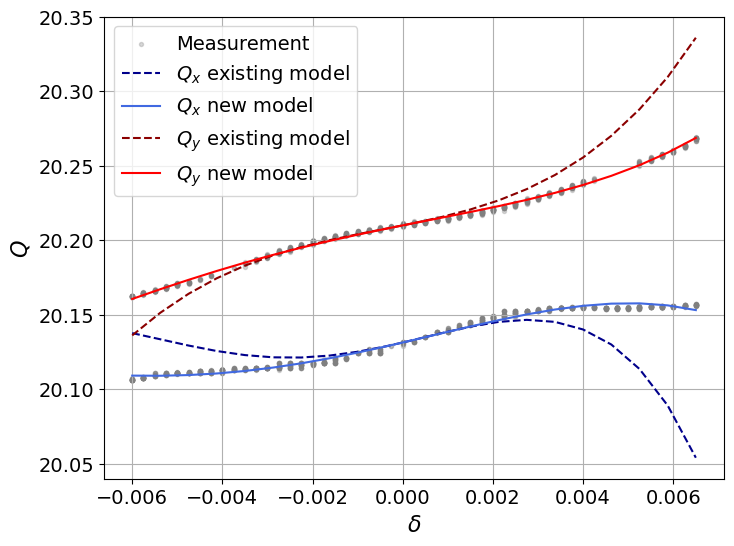

In [53]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,1, figsize=(8,6))
ax.scatter(data_qx['delta'], 20 + np.array(data_qx['qx']), label="Measurement", color = 'gray', alpha=0.3, s=8.5)
ax.plot(d_model2, qx_model2, label=r"$Q_x$ existing model", color = 'darkblue', linestyle='dashed')
ax.plot(d_model3, qx_model3, label=r"$Q_x$ new model", color = 'royalblue')
ax.scatter(data_qy['delta'], 20 + np.array(data_qy['qy']), color = 'gray', alpha=0.3, s=8.5)
ax.plot(d_model2, qy_model2, label=r"$Q_y$ existing model", color = 'darkred', linestyle='dashed')
ax.plot(d_model3, qy_model3, label=r"$Q_y$ new model", color = 'red')
ax.grid()
ax.set_xlabel(r"$\delta$", fontsize=16)
ax.set_ylabel(r"$Q$", fontsize=16)
ax.legend()

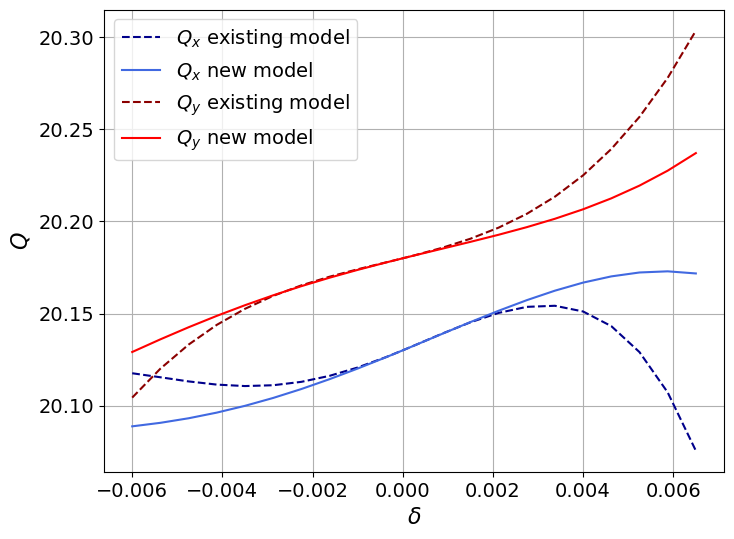

In [56]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1,1, figsize=(8,6))
# ax.scatter(data_qx['delta'], 20 + np.array(data_qx['qx']), label="Measurement", color = 'gray', alpha=0.3, s=8.5)
ax.plot(d_model2, qx_model2, label=r"$Q_x$ existing model", color = 'darkblue', linestyle='dashed')
ax.plot(d_model3, qx_model3, label=r"$Q_x$ new model", color = 'royalblue')
# ax.scatter(data_qy['delta'], 20 + np.array(data_qy['qy']), color = 'gray', alpha=0.3, s=8.5)
ax.plot(d_model2, qy_model2, label=r"$Q_y$ existing model", color = 'darkred', linestyle='dashed')
ax.plot(d_model3, qy_model3, label=r"$Q_y$ new model", color = 'red')
ax.grid()
ax.set_xlabel(r"$\delta$", fontsize=16)
ax.set_ylabel(r"$Q$", fontsize=16)
ax.legend()